## Unemployment Analysis with Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Dataset

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# Data Inspection

In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nInformation:")
df.info()
print("\nSummary Statistics:")
display(df.describe())

Shape: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


# Data Cleaning

In [7]:
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
print(df.isnull().sum())
df = df.dropna()
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Shape after cleaning: (740, 7)


# Cleaned Dataset

In [8]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


# Region-wise Average Unemployment Rate

/tmp/ipykernel_1960/4158767148.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.index,y=region_avg.values,palette="viridis")


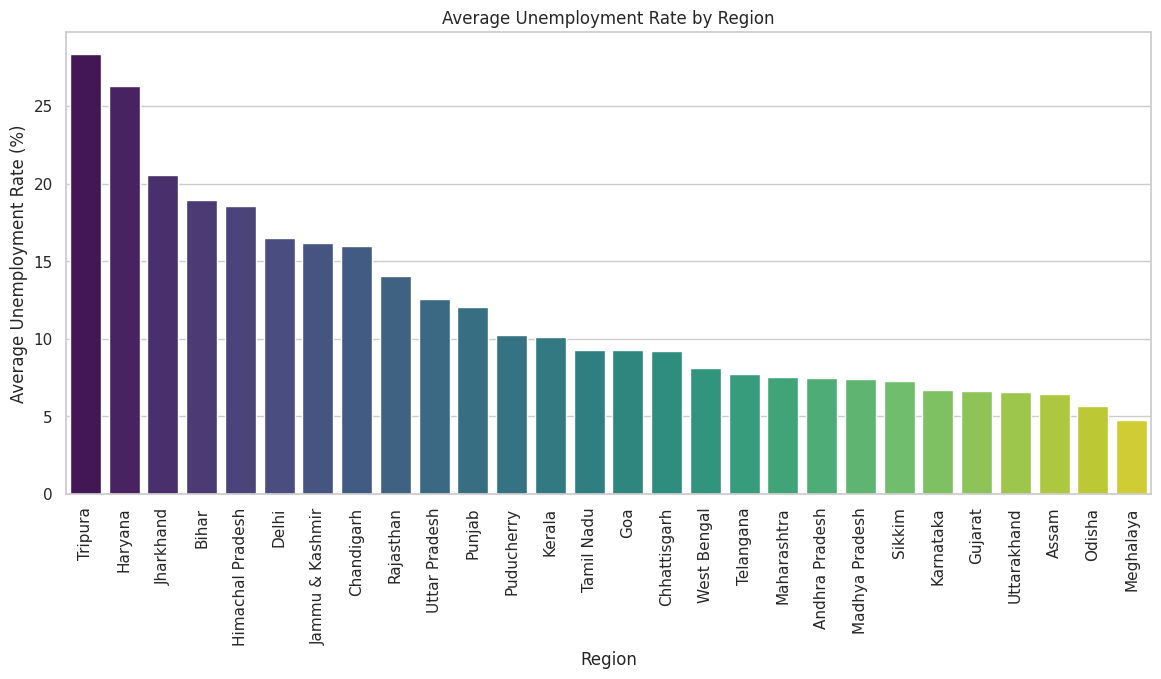

In [9]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=region_avg.index,y=region_avg.values,palette="viridis")
plt.xticks(rotation=90)
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

This bar chart shows the average unemployment rate across different regions of India. Higher bars indicate regions with consistently higher unemployment.

# Month Wise Trend

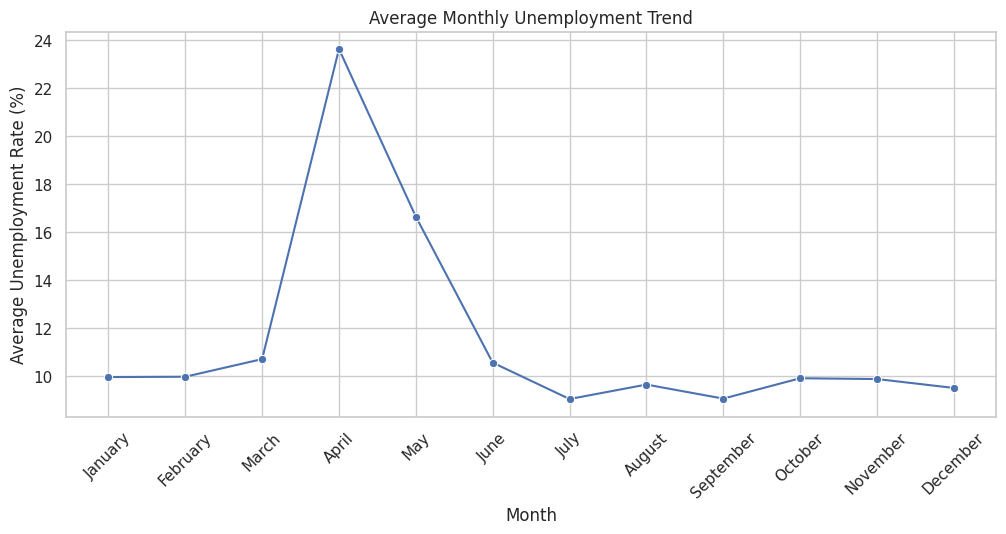

In [10]:
df["Month"] = df["Date"].dt.month_name()
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean().reindex(month_order)
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_avg.index,y=monthly_avg.values,marker="o")
plt.xticks(rotation=45)
plt.title("Average Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

This line chart illustrates how unemployment changes across different months.

# Time Series Analysis

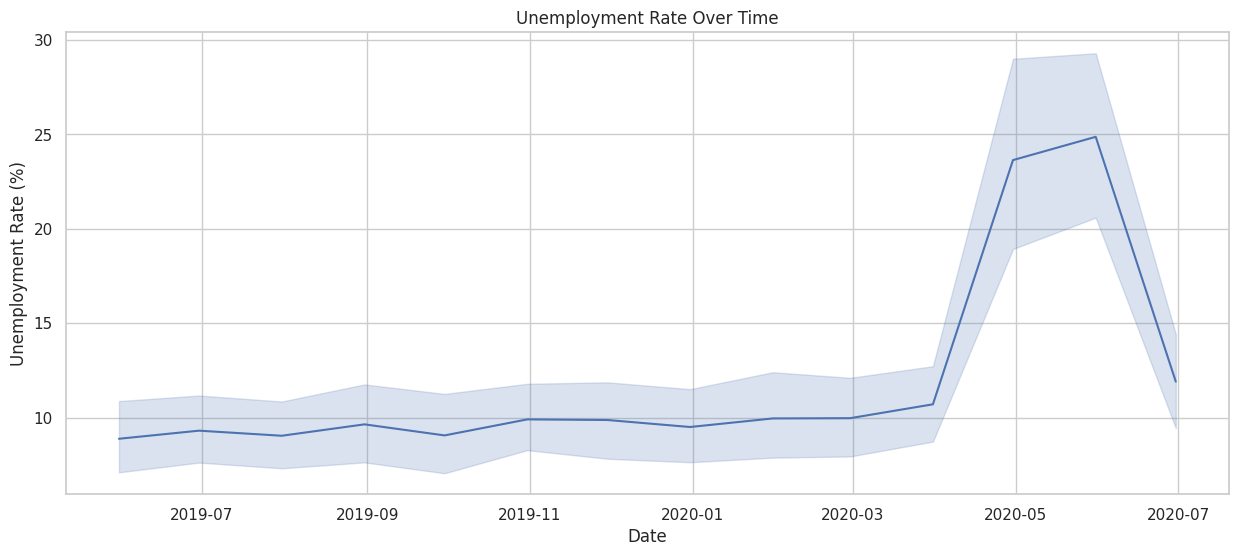

In [11]:
plt.figure(figsize=(15,6))
sns.lineplot(data=df,x="Date",y="Estimated Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

This time-series chart visualizes changes in unemployment over time and helps identify trends and sudden spikes.

# Top 10 Regions

/tmp/ipykernel_1960/1640643267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values,y=top10.index,palette="Reds_r")


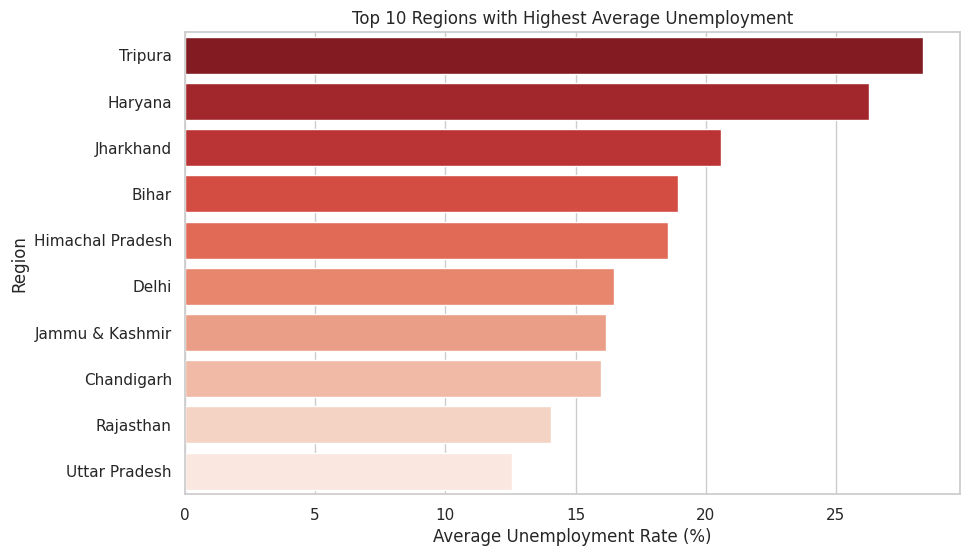

In [12]:
top10 = region_avg.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top10.values,y=top10.index,palette="Reds_r")
plt.title("Top 10 Regions with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()

This visualization highlights the ten regions with the highest average unemployment rate.

# Urban Vs Rural

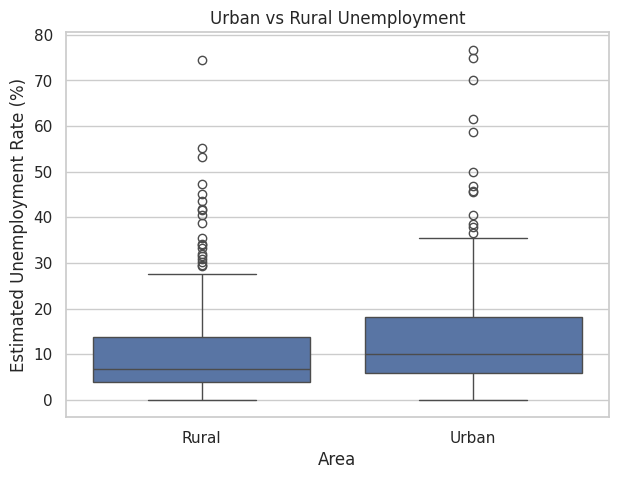

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Area",y="Estimated Unemployment Rate (%)",data=df)
plt.title("Urban vs Rural Unemployment")
plt.show()

This boxplot compares unemployment distributions between urban and rural areas.

# Correlation Heatmap

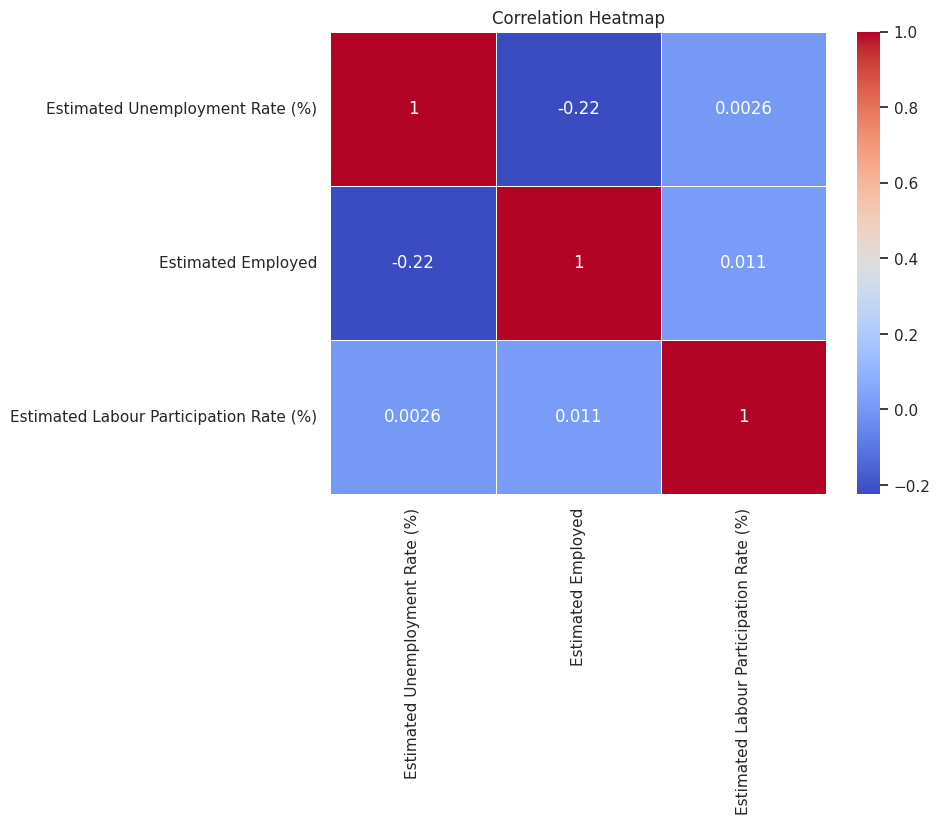

In [15]:
plt.figure(figsize=(8,6))
correlation = df[["Estimated Unemployment Rate (%)","Estimated Employed","Estimated Labour Participation Rate (%)"]].corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between unemployment, employment, and labour participation rate.

# Pre-COVID Vs Post-COVID Analysis

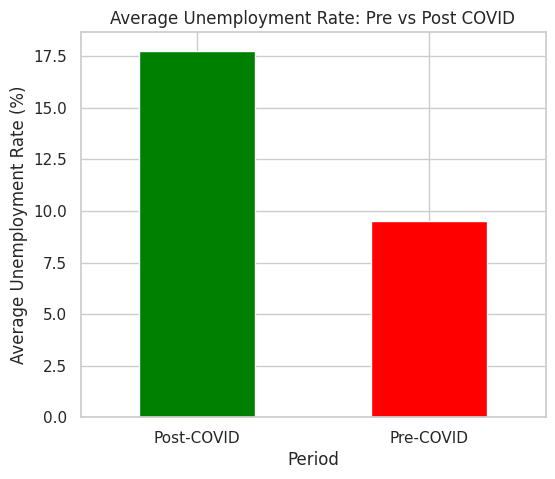

In [16]:
covid_date = pd.Timestamp("2020-03-25")
df["Period"] = np.where(df["Date"] < covid_date,"Pre-COVID","Post-COVID")
comparison = df.groupby("Period")["Estimated Unemployment Rate (%)"].mean()
plt.figure(figsize=(6,5))
comparison.plot(kind="bar",color=["green","red"])
plt.title("Average Unemployment Rate: Pre vs Post COVID")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.show()

This chart compares the average unemployment rate before and after the COVID-19 lockdown, highlighting its impact on employment.

# Project Insights



1-Some regions experienced significantly higher unemployment than others
2-Unemployment showed noticeable monthly variations.
3-COVID-19 increased the average unemployment rate.
6-Labour participation and employment have measurable correlations with unemployment.
5-Urban and rural unemployment distributions differ.